In [1]:
# Keep the figures from changing between runs.
# Run this before any other cell so that both the seed used for sampling and
# GMM fitting and the timestamp embedded in the saved EPS / PDF stay fixed.
from pgot import set_reproducible

set_reproducible()

Generator(PCG64) at 0x7FD1E80BBA00

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from pgot import (
    GaussianMixture,
    entropic_partial_displacement_interpolation,
    submixture_pdf,
)

In [3]:
# ---------------------------------------
# Source and target mixtures (Section 7.1)
# ---------------------------------------
alpha_A = np.array([0.5, 0.5])
means_A = np.array([[-8.0, -5.0], [1.0, -8.0]])
covs_A = 0.2 * np.array([[[1, 0.2], [0.2, 1]], [[1, -0.1], [-0.1, 1]]])
Gmm_1 = GaussianMixture(alpha_A, means_A, covs_A)

alpha_B = np.array([0.45, 0.45, 0.1])
means_B = np.array([[-3.5, 3.5], [3.5, 3.5], [9.0, 7.5]])
covs_B = 0.2 * np.array(
    [[[1, -0.1], [-0.1, 1]], [[1, 0.2], [0.2, 1]], [[1, 0.0], [0.0, 1]]]
)
Gmm_2 = GaussianMixture(alpha_B, means_B, covs_B)

# ---------------------------------------
# Shared evaluation grid
# ---------------------------------------
GRID_LIM = 12
GRID_N = 400
_axis = np.linspace(-GRID_LIM, GRID_LIM, GRID_N)
GX, GY = np.meshgrid(_axis, _axis)
GRID_POINTS = np.column_stack([GX.ravel(), GY.ravel()])


def log_levels(z_max, n=7, decades=1e-3):
    """Logarithmic contour levels ending at ``z_max``."""
    return np.logspace(np.log10(z_max * decades), np.log10(z_max), n)


def draw_density(values, levels, cmap, axis):
    """Fill contours of a density already evaluated on the shared grid."""
    axis.contourf(
        GX,
        GY,
        values.reshape(GX.shape),
        levels=levels,
        cmap=cmap,
        norm=LogNorm(vmin=levels[0], vmax=levels[-1]),
        alpha=1,
    )
    axis.set_aspect("equal", adjustable="box")


# The two endpoint mixtures are identical in every panel, so a single level
# set per mixture keeps the background comparable across the whole figure.
DENSITY_A = Gmm_1.pdf(GRID_POINTS)
DENSITY_B = Gmm_2.pdf(GRID_POINTS)
LEVELS_A = log_levels(DENSITY_A.max())
LEVELS_B = log_levels(DENSITY_B.max())

In [4]:
# Evaluate (4.18) for every panel before plotting, so that all panels can
# share one density scale. The weights are the coupling entries themselves:
# no threshold and no renormalization, so each panel integrates to its own
# matched mass Z_lambda rather than to one.
t_list = np.linspace(0, 1, 5)
configs = [
    (r"$\varepsilon=0.03,\ \Lambda = 0.25$", 0.25, 0.03),
    (r"$\varepsilon=0.1,\ \Lambda = 0.25$", 0.25, 0.1),
    (r"$\varepsilon=0.03,\ \Lambda = 0.5$", 0.5, 0.03),
]

panel_density = {}
row_mass = {}
for row, (label, Lambda, epsilon) in enumerate(configs):
    for col, t in enumerate(t_list):
        (weights, means, covs), info = entropic_partial_displacement_interpolation(
            Gmm_1,
            Gmm_2,
            t,
            epsilon=epsilon,
            Lambda=Lambda,
            log=True,
        )
        panel_density[(row, col)] = submixture_pdf(GRID_POINTS, weights, means, covs)
        row_mass[row] = info["matched_mass"]
    print(
        f"row {row + 1}: lambda = {Lambda}, epsilon = {epsilon}, "
        f"matched mass Z_lambda = {row_mass[row]:.7f}, "
        f"coupling entries kept = {len(weights)}"
    )

# One common level set for all interpolation panels: the mass differences
# between rows are only visible if the density scale does not follow each
# panel's own maximum.
LEVELS_T = log_levels(max(v.max() for v in panel_density.values()))
print(f"shared density levels: {LEVELS_T[0]:.3e} .. {LEVELS_T[-1]:.3e}")

row 1: lambda = 0.25, epsilon = 0.03, matched mass Z_lambda = 0.8875742, coupling entries kept = 6


row 2: lambda = 0.25, epsilon = 0.1, matched mass Z_lambda = 0.6807441, coupling entries kept = 6


row 3: lambda = 0.5, epsilon = 0.03, matched mass Z_lambda = 0.9937141, coupling entries kept = 6
shared density levels: 4.001e-04 .. 4.001e-01


/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(


/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(


/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(
/tmp/ipykernel_192036/3206790946.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axis.contourf(


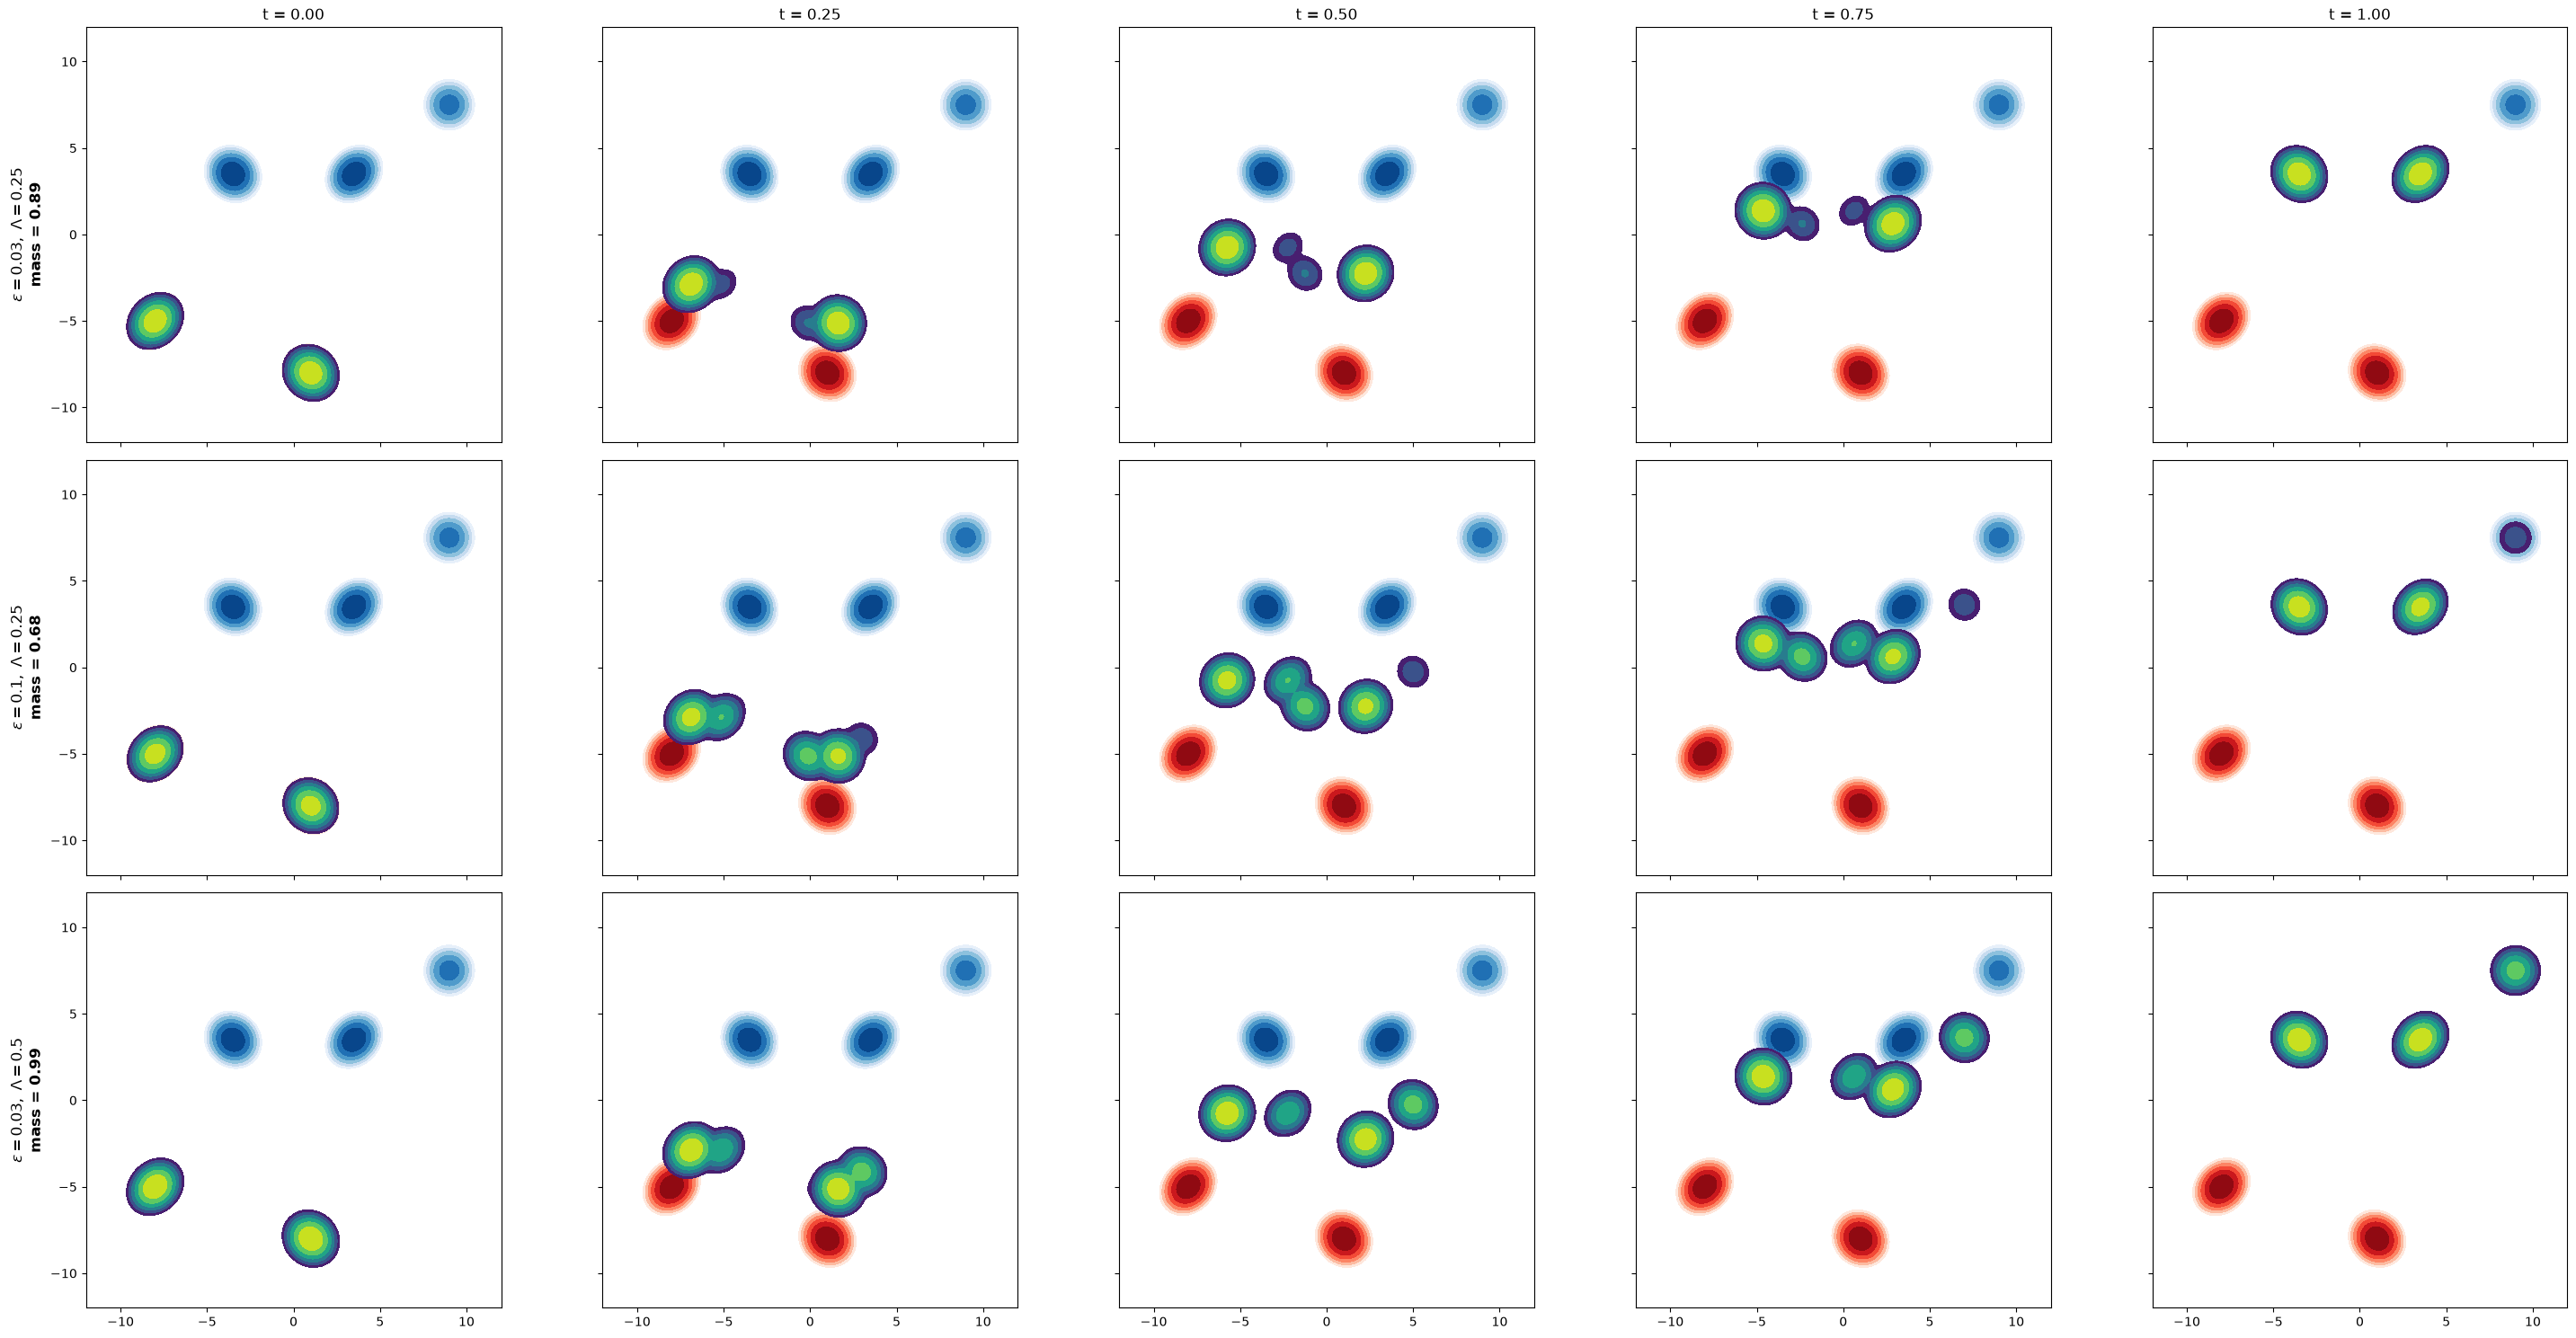

Saved: comparison_high_res.eps, comparison_high_res.pdf


In [5]:
fig, axes = plt.subplots(len(configs), len(t_list), figsize=(30, 15))

for row, (label, Lambda, epsilon) in enumerate(configs):
    for col, t in enumerate(t_list):
        ax = axes[row, col]
        draw_density(DENSITY_A, LEVELS_A, "Reds", ax)
        draw_density(DENSITY_B, LEVELS_B, "Blues", ax)
        draw_density(panel_density[(row, col)], LEVELS_T, "viridis", ax)

        ax.set_xlim(-GRID_LIM, GRID_LIM)
        ax.set_ylim(-GRID_LIM, GRID_LIM)
        if row == 0:
            ax.set_title(f"t = {t:.2f}")
        if col == 0:
            ax.set_ylabel(
                f"{label}\nmass = {row_mass[row]:.2f}",
                fontsize=12,
                fontweight="bold",
            )
        if col > 0:
            ax.set_yticklabels([])
        if row < len(configs) - 1:
            ax.set_xticklabels([])

plt.tight_layout()

output_eps = os.path.join("comparison_high_res.eps")
output_pdf = os.path.join("comparison_high_res.pdf")
plt.savefig(output_eps, format="eps", dpi=300, bbox_inches="tight")
plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved: {output_eps}, {output_pdf}")